In [31]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter

In [32]:
PROJECT_ROOT = Path("..")
DATASET_DIR = PROJECT_ROOT/"datasets"/"raw"/"astro_dataset_maxia"

TRAIN_DIR = DATASET_DIR/"training"
TEST_DIR = DATASET_DIR/"test"
VAL_DIR = DATASET_DIR/"validation"

print(TRAIN_DIR)
print(TEST_DIR)
print(VAL_DIR)

..\datasets\raw\astro_dataset_maxia\training
..\datasets\raw\astro_dataset_maxia\test
..\datasets\raw\astro_dataset_maxia\validation


In [34]:
classes = sorted(
    [
        folder.name
        for folder in TRAIN_DIR.iterdir()
        if folder.is_dir()
    ]
)
print(f"Number of classes: {len(classes)}")
print("Classes Found:")
print(classes)

Number of classes: 12
Classes Found:
['asteroid', 'black_hole', 'earth', 'galaxy', 'jupiter', 'mars', 'mercury', 'neptune', 'pluto', 'saturn', 'uranus', 'venus']


In [37]:
splits = {
    "Traininig": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}

for split_name, split_path in splits.items():
    print(f"\n{split_name}")
    total = 0
    for cls in classes:
        count = len(list((split_path/cls).glob("*")))
        total += count
        print(f"{cls:<15} {count}")
        
    print("-" * 30)
    print(f"Total Images: {total}")


Traininig
asteroid        212
black_hole      185
earth           209
galaxy          185
jupiter         202
mars            215
mercury         201
neptune         202
pluto           201
saturn          201
uranus          202
venus           201
------------------------------
Total Images: 2416

Validation
asteroid        42
black_hole      48
earth           59
galaxy          49
jupiter         57
mars            61
mercury         57
neptune         57
pluto           57
saturn          57
uranus          57
venus           57
------------------------------
Total Images: 658

Test
asteroid        29
black_hole      31
earth           29
galaxy          30
jupiter         28
mars            30
mercury         28
neptune         28
pluto           28
saturn          28
uranus          28
venus           28
------------------------------
Total Images: 345


In [42]:
summary = []

for cls in classes:
    train_count = len(list((TRAIN_DIR/cls).glob("*")))
    val_count = len(list((VAL_DIR/cls).glob("*")))
    test_count = len(list((TEST_DIR/cls).glob("*")))
    
    summary.append({
        "Class": cls,
        "Train": train_count,
        "Validation": val_count,
        "Test": test_count,
        "Total": train_count + val_count + test_count
        
    })
    
    df = pd.DataFrame(summary)
    df

In [44]:
print(f"Number of Classes : {len(classes)}")
print(f"Training Images : {df['Train'].sum()}")
print(f"Validation Images : {df['Validation'].sum()}")
print(f"Testing Images : {df['Test'].sum()}")
print(f"Total Images : {df['Total'].sum()}")

Number of Classes : 12
Training Images : 2416
Validation Images : 658
Testing Images : 345
Total Images : 3419


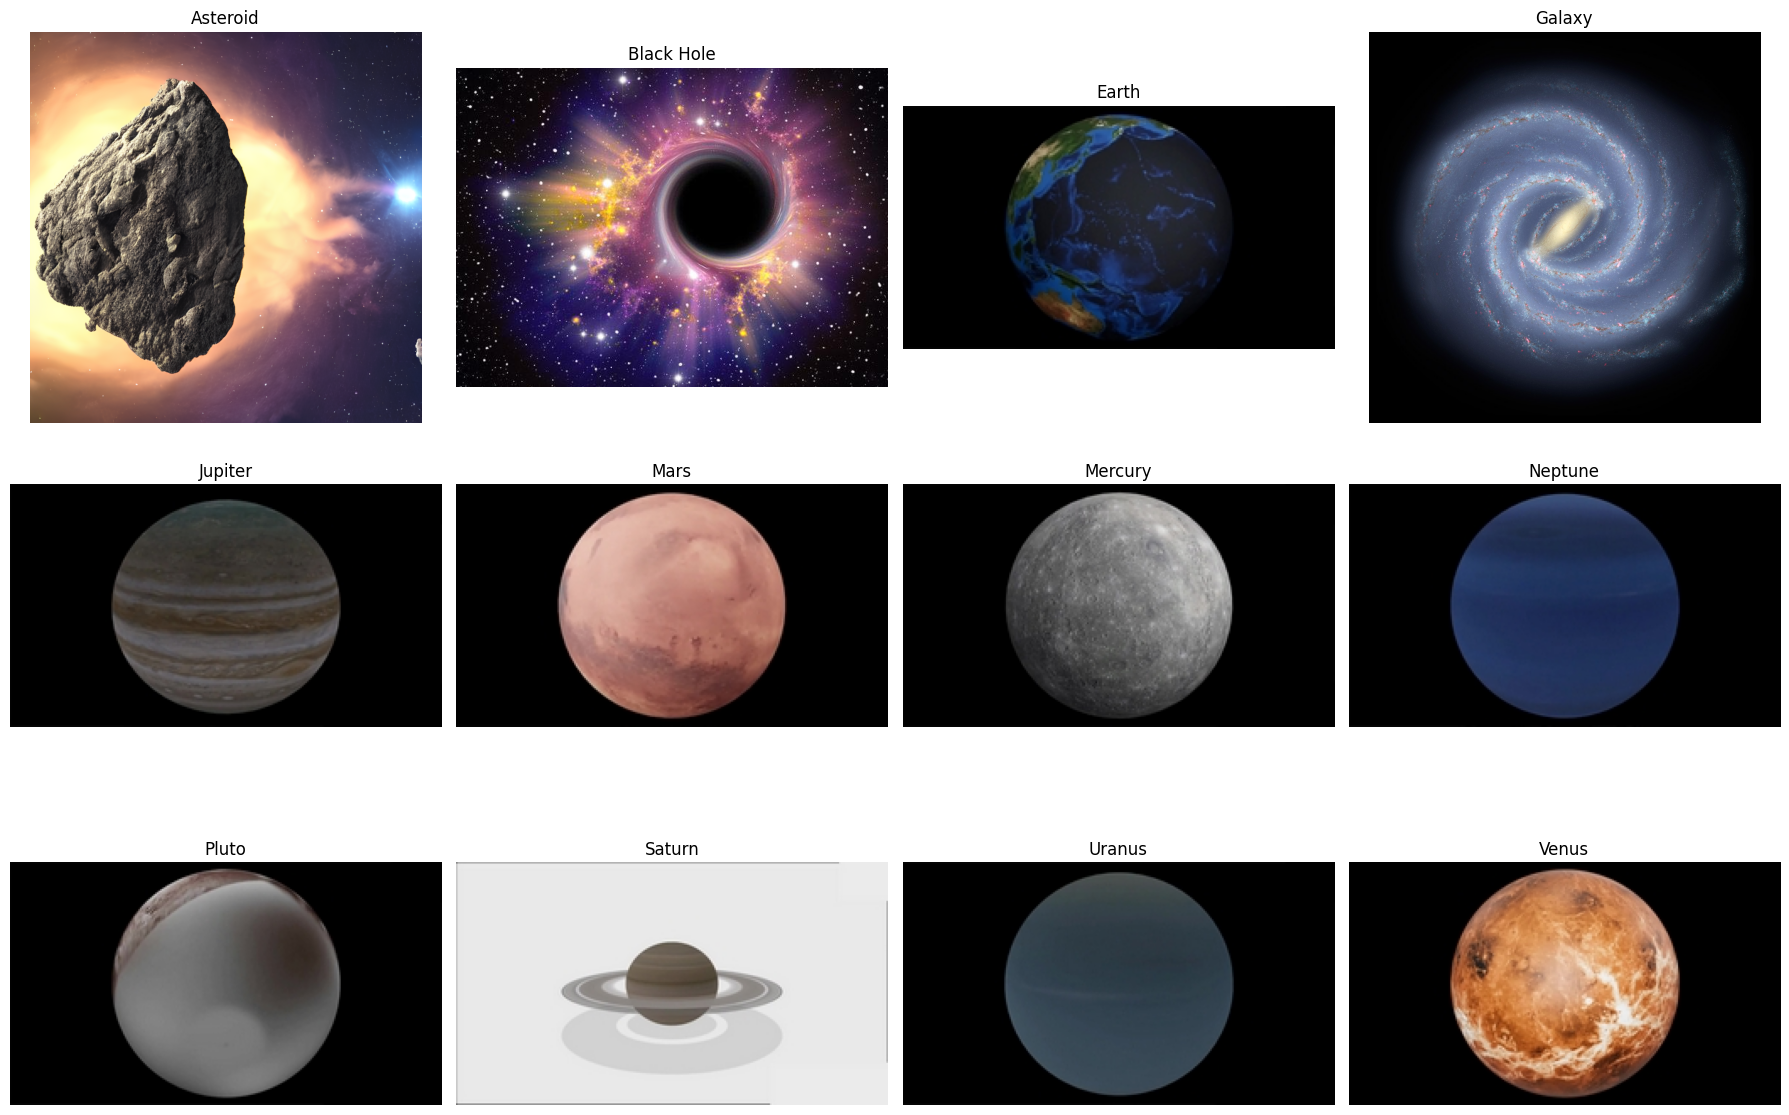

In [41]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

axes = axes.flatten()

for i, cls in enumerate(classes):
    image_path = next((TRAIN_DIR / cls).glob("*"))
    img = Image.open(image_path)

    axes[i].imshow(img)
    axes[i].set_title(cls.replace("_", " ").title())
    axes[i].axis("off")

plt.tight_layout()
plt.show()